# Example 09: Custom Data Pipelines with HDF5

When your dataset doesn't fit the standard `create_dls` pattern -- custom
readers, different signal combinations, fixed batch counts -- you need a
custom pipeline. This example shows how to compose tsfast's building readers
to create flexible data loading for any HDF5 dataset. You will learn how
each primitive works on its own, and then combine them into a complete
training pipeline.

## Prerequisites

- [Example 00: Your First Model](00_your_first_model.ipynb)
- [Example 01: Understanding the Data Pipeline](01_data_pipeline.ipynb)

## Setup

In [1]:
from pathlib import Path

from torch.utils.data import DataLoader

from tsfast.tsdata import (
    WindowedDataset, HDF5Signals, SourceEntry, DataLoaders,
    create_dls, create_dls_from_readers, get_hdf_files, split_by_parent,
)
from tsfast.training import RNNLearner, fun_rmse

## Finding HDF5 Files

The first step in any custom pipeline is discovering which files exist on
disk. `get_hdf_files` recursively searches a directory for `.hdf5` and `.h5`
files and returns them as a sorted list of `Path` objects.

In [2]:
def _find_project_root(marker: str = "test_data") -> Path:
    """Walk up from script/notebook location to find the project root."""
    try:
        start = Path(__file__).resolve().parent
    except NameError:
        start = Path(".").resolve()
    p = start
    while p != p.parent:
        if (p / marker).is_dir():
            return p
        p = p.parent
    raise FileNotFoundError(f"Could not find '{marker}' directory above {start}")

_root = _find_project_root()

data_path = _root / "test_data" / "WienerHammerstein"

files = get_hdf_files(data_path)
print(f"Found {len(files)} HDF5 files:")
for f in files:
    print(f"  {f.parent.name}/{f.name}")

Found 3 HDF5 files:
  test/WienerHammerstein_test.hdf5
  train/WienerHammerstein_train.hdf5
  valid/WienerHammerstein_valid.hdf5


## Converting Your Data to HDF5

TSFast expects data in HDF5 format. If your data is in CSV files or numpy
arrays, convert it with a few lines of code. Each HDF5 file should contain
one experiment or recording, with each signal stored as a 1-D dataset.
Organize files into `train/`, `valid/`, and optionally `test/`
subdirectories.

**From numpy arrays:**

```python
import h5py
import numpy as np

u = np.load('my_input.npy')   # shape: (timesteps,)
y = np.load('my_output.npy')  # shape: (timesteps,)

with h5py.File('train/experiment_01.hdf5', 'w') as f:
    f.create_dataset('u', data=u)
    f.create_dataset('y', data=y)
```

**From CSV files:**

```python
import pandas as pd
import h5py

df = pd.read_csv('experiment.csv')
with h5py.File('train/experiment_01.hdf5', 'w') as f:
    f.create_dataset('u', data=df['input_column'].values)
    f.create_dataset('y', data=df['output_column'].values)
```

Then load with `create_dls(u=['u'], y=['y'], dataset=path)` as shown below.

## The Standard Approach

Before building anything custom, let's see the standard `create_dls` call for
reference. It handles file discovery, windowing, splitting, and normalization
in a single function. All the primitives we explore below are composed
internally by `create_dls`.

Parameters:

- **`u=['u']`** -- input signal column names in the HDF5 files.
- **`y=['y']`** -- output signal column names the model learns to predict.
- **`dataset`** -- path to a directory with `train/`, `valid/`, and `test/`
  subdirectories containing HDF5 files.
- **`win_sz=200`** -- window size in time steps. Each training sample is a
  200-step slice.
- **`stp_sz=50`** -- step size (stride) between consecutive windows.
- **`bs=32`** -- batch size.

We build `dls_standard` purely as a reference point -- the rest of this
example reconstructs the same pipeline from its primitives.

In [3]:
dls_standard = create_dls(
    u=['u'], y=['y'],
    dataset=data_path,
    win_sz=200, stp_sz=50,
    bs=32,
)
xb, yb = next(iter(dls_standard.train))
print(f"Input batch: {tuple(xb.shape)}, target batch: {tuple(yb.shape)}")

Input batch: (32, 200, 1), target batch: (32, 200, 1)


## Building a Custom Pipeline Step by Step

Now let's rebuild the same pipeline manually to understand each component.
This knowledge lets you customize any part of the pipeline when the standard
approach doesn't fit your needs.

### Step 1: Split Files by Directory

`split_by_parent` inspects each file's parent directory name and returns
`(train_indices, valid_indices)`. Files under a `train/` directory go to
training, files under `valid/` go to validation.

In [4]:
train_idx, valid_idx = split_by_parent(files)
train_files = [files[i] for i in train_idx]
valid_files = [files[i] for i in valid_idx]
print(f"Train files: {len(train_files)}, Valid files: {len(valid_files)}")

Train files: 1, Valid files: 1


### Step 2: Define Signal Readers

`HDF5Signals` defines which datasets to read from each HDF5 file. The first
reader reads input signals, the second reads target signals.

In [5]:
inputs = HDF5Signals(['u'])
targets = HDF5Signals(['y'])

### Step 3: Create WindowedDatasets

`WindowedDataset` takes a list of `SourceEntry` objects and the signal readers,
then creates overlapping windows of the specified size. Each sample is a
`(input_tensor, target_tensor)` tuple.

- **`win_sz=200`** -- each window is 200 timesteps long
- **`stp_sz=50`** -- windows overlap with a stride of 50 timesteps

In [6]:
train_entries = [SourceEntry(path=str(f)) for f in train_files]
valid_entries = [SourceEntry(path=str(f)) for f in valid_files]

train_ds = WindowedDataset(train_entries, inputs=inputs, targets=targets, win_sz=200, stp_sz=50)
valid_ds = WindowedDataset(valid_entries, inputs=inputs, targets=targets, win_sz=200, stp_sz=50)

print(f"Train windows: {len(train_ds)}")
print(f"Valid windows: {len(valid_ds)}")

Train windows: 1597
Valid windows: 397


### Step 4: Create DataLoaders

Wrap the datasets in standard PyTorch DataLoaders, then bundle them in
tsfast's `DataLoaders` container for compatibility with the Learner.

In [7]:
train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)
valid_dl = DataLoader(valid_ds, batch_size=32, shuffle=False)
dls_custom = DataLoaders(train_dl, valid_dl)

## Using create_dls_from_readers

For a more concise approach, `create_dls_from_readers` handles the
`WindowedDataset` and `DataLoader` construction for you. Two defaults differ
from the manual pipeline above: `n_batches_train` defaults to 300 (random
sampling with replacement instead of iterating every window once), and the
validation stride defaults to `win_sz`. Passing `n_batches_train=None` and
`valid_stp_sz=50` matches `dls_custom`: the same windows, sampled once per
epoch.

In [8]:
dls_readers = create_dls_from_readers(
    inputs=inputs, targets=targets,
    train_files=train_files, valid_files=valid_files,
    win_sz=200, stp_sz=50, valid_stp_sz=50, bs=32,
    n_batches_train=None,
)

assert len(dls_readers.train.dataset) == len(dls_custom.train.dataset)
assert len(dls_readers.valid.dataset) == len(dls_custom.valid.dataset)
xb_c, _ = next(iter(dls_custom.train))
xb_r, _ = next(iter(dls_readers.train))
print(f"Custom batch shape:  {tuple(xb_c.shape)}")
print(f"Readers batch shape: {tuple(xb_r.shape)}")

Custom batch shape:  (32, 200, 1)
Readers batch shape: (32, 200, 1)


## Fixed Batch Counts

When datasets have very different sizes, you may want a fixed number of
batches per epoch regardless of how many windows exist. Pass
`n_batches_train` to `create_dls_from_readers` or `create_dls` -- both
default to `n_batches_train=300`.

This uses `RandomSampler` with `replacement=True` to oversample when there
are fewer windows than requested, ensuring consistent training time across
datasets of varying size.

In [9]:
dls_nbatch = create_dls_from_readers(
    inputs=inputs, targets=targets,
    train_files=train_files, valid_files=valid_files,
    win_sz=200, stp_sz=50, bs=32,
    n_batches_train=100,
)
print(f"Training batches per epoch: {len(dls_nbatch.train)}")
print(f"Validation batches per epoch: {len(dls_nbatch.valid)}")

Training batches per epoch: 100
Validation batches per epoch: 4


You can also build fixed-batch DataLoaders manually using PyTorch's
`RandomSampler`:

```python
n_samples = 100 * 32  # 100 batches * 32 batch size
sampler = RandomSampler(train_ds, replacement=True, num_samples=n_samples)
train_dl = DataLoader(train_ds, batch_size=32, sampler=sampler)
```

## Training with the Custom Pipeline

Let's train an LSTM on the custom DataLoaders to verify everything works
end-to-end. `RNNLearner` creates a recurrent neural network wrapped in a
Learner.

Parameters:

- **`dls_custom`** -- the DataLoaders we built manually above.
- **`rnn_type='lstm'`** -- use Long Short-Term Memory cells.
- **`hidden_size=40`** -- number of hidden units in the LSTM.
- **`metrics=[fun_rmse]`** -- track root mean squared error during training.

In [10]:
lrn = RNNLearner(dls_custom, rnn_type='lstm', hidden_size=40, metrics=[fun_rmse])
lrn.fit_flat_cos(n_epoch=5, lr=3e-3)

Epoch 1/5:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 1/5:  62%|██████▏   | 31/50 [00:00<00:00, 60.52it/s]

Epoch 1/5: 100%|██████████| 50/50 [00:00<00:00, 60.52it/s, train=0.1543 | valid=0.0759 | fun_rmse=0.1078]

Epoch 1/5: 100%|██████████| 50/50 [00:00<00:00, 53.55it/s, train=0.1543 | valid=0.0759 | fun_rmse=0.1078]

Epoch 2/5:   0%|          | 0/50 [00:00<?, ?it/s]

...

Epoch 4/5: 100%|██████████| 50/50 [00:00<00:00, 57.75it/s, train=0.0294 | valid=0.0284 | fun_rmse=0.0671]

Epoch 5/5:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 5/5:  74%|███████▍  | 37/50 [00:00<00:00, 73.43it/s]

Epoch 5/5: 100%|██████████| 50/50 [00:00<00:00, 73.43it/s, train=0.0265 | valid=0.0270 | fun_rmse=0.0666]

Epoch 5/5: 100%|██████████| 50/50 [00:00<00:00, 58.78it/s, train=0.0265 | valid=0.0270 | fun_rmse=0.0666]

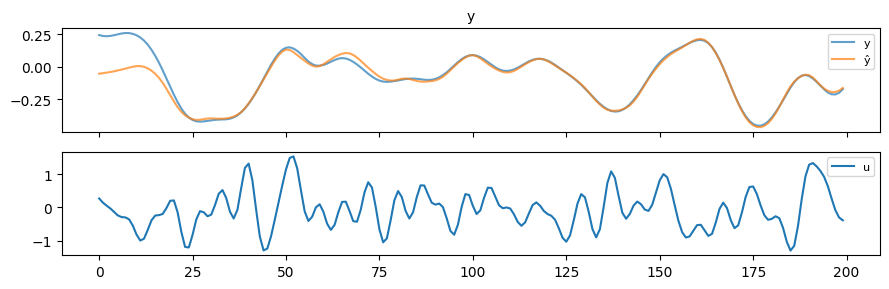

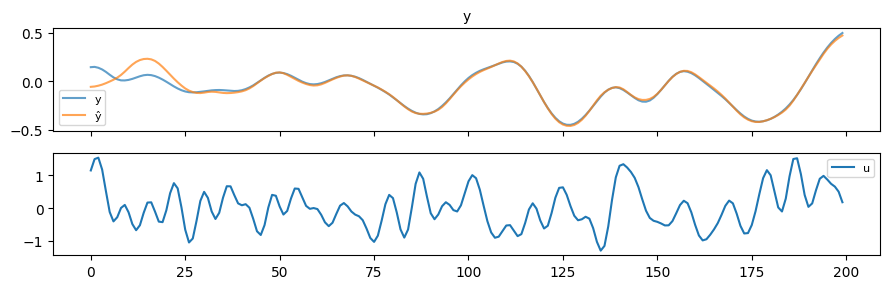

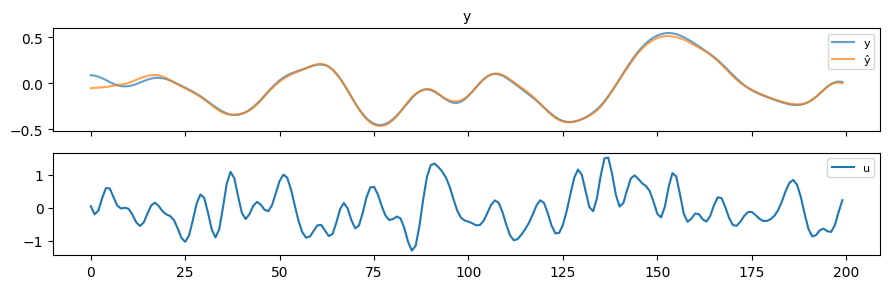

In [11]:
lrn.show_results(max_n=3)

## Key Takeaways

- **`get_hdf_files`** discovers HDF5 files recursively in a directory tree.
- **`split_by_parent`** splits files into train/validation sets based on
  parent directory names (e.g., `train/` vs `valid/`).
- **`HDF5Signals`** defines which datasets to extract from HDF5 files.
- **`WindowedDataset`** creates overlapping windows from HDF5 files, with
  configurable window size and step size.
- **`SourceEntry`** wraps a file path with optional resampling metadata.
- **`DataLoaders`** bundles train/valid DataLoaders for the Learner.
- **`create_dls_from_readers`** handles dataset + DataLoader construction
  from readers and file lists, including `n_batches_train` for fixed batch
  counts.
- The standard **`create_dls`** composes these same primitives internally --
  understanding them lets you customize any part of the pipeline.